# Attribution Modeling

## Objective

This notebook analyzes the contribution of different marketing channels to customer conversions using attribution models.

The analysis includes:

- First Touch Attribution
- Last Touch Attribution
- Revenue Attribution
- ROAS by Channel

## Attribution Insights

1. Email has the highest paid ROAS at 0.31.
2. TikTok performs better than Google Search and LinkedIn.
3. Google Search receives the largest budget allocation but has relatively low ROAS.
4. Organic traffic generates revenue without paid marketing spend.
5. Future budget allocation should prioritize high-performing channels such as Email and TikTok.

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
ad_df = pd.read_csv("ad_spend_data.csv")

web_df = pd.read_csv("web_analytics_log.csv")

crm_df = pd.read_csv("crm_conversion_data.csv")

In [91]:
web_df["timestamp"] = pd.to_datetime(
    web_df["timestamp"]
)

crm_df["conversion_date"] = pd.to_datetime(
    crm_df["conversion_date"]
)

In [92]:
first_touch = (
    web_df
    .sort_values("timestamp")
    .groupby("user_id")
    .first()
    .reset_index()
)

In [93]:
first_touch.head()

,user_id,session_id,timestamp,channel,utm_source,utm_medium,utm_campaign,page_visited,session_duration_sec,device
0,USR_00001,SES_323717,2024-03-07 21:21:00,Meta_Facebook,facebook,cpc,FB_Awareness,/pricing,399,desktop
1,USR_00002,SES_396567,2024-03-25 00:58:00,Meta_Facebook,facebook,cpc,FB_Retargeting,/blog,871,desktop
2,USR_00003,SES_338703,2024-03-06 08:26:00,Google_Search,google,cpc,GSearch_Generic,/about,491,tablet
3,USR_00004,SES_415989,2024-01-07 19:05:00,Meta_Facebook,facebook,cpc,FB_Awareness,/pricing,813,desktop
4,USR_00005,SES_404771,2024-01-24 21:04:00,Email,email,email,Email_Retention,/pricing,130,mobile


In [94]:
first_touch_channel = (
    first_touch["channel"]
    .value_counts()
)

first_touch_channel

channel
Google_Search    557
Meta_Facebook    508
TikTok           328
Email            231
Organic          212
LinkedIn         164
Name: count, dtype: int64

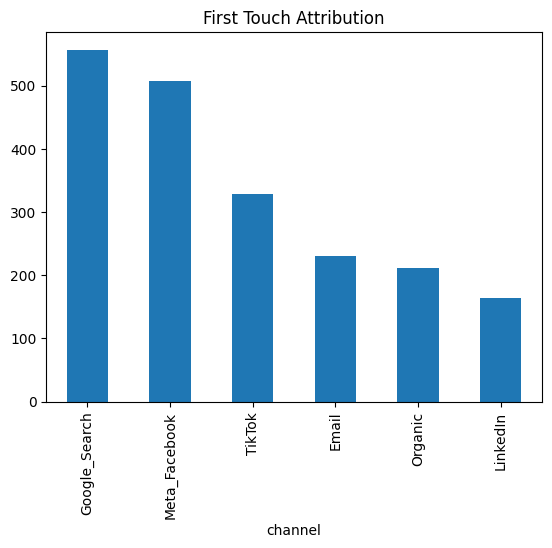

In [95]:
first_touch_channel.plot(
    kind="bar"
)

plt.title(
    "First Touch Attribution"
)

plt.show()

In [96]:
last_touch = (
    web_df
    .sort_values("timestamp")
    .groupby("user_id")
    .last()
    .reset_index()
)

In [97]:
last_touch_channel = (
    last_touch["channel"]
    .value_counts()
)

last_touch_channel

channel
Google_Search    596
Meta_Facebook    477
TikTok           309
Email            209
LinkedIn         206
Organic          203
Name: count, dtype: int64

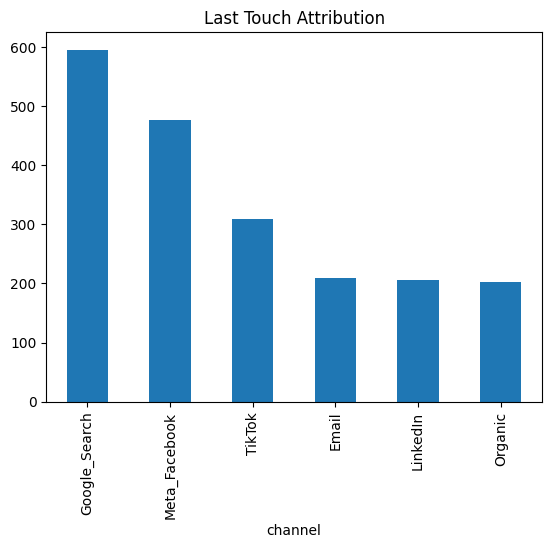

In [98]:
last_touch_channel.plot(
    kind="bar"
)

plt.title(
    "Last Touch Attribution"
)

plt.show()

In [99]:
revenue_channel = (
    crm_df
    .groupby("last_touch_channel")
    ["revenue_usd"]
    .sum()
    .sort_values(
        ascending=False
    )
)

revenue_channel

last_touch_channel
Google_Search    43583.44
Meta_Facebook    41564.63
TikTok           24587.92
LinkedIn         16716.83
Organic          16696.59
Email            14329.86
Name: revenue_usd, dtype: float64

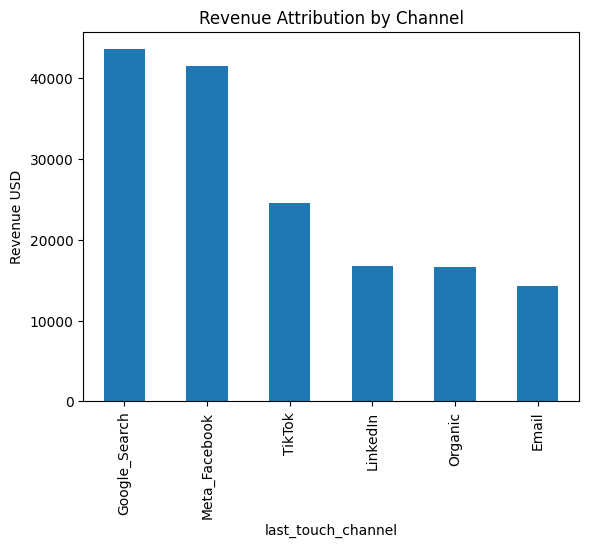

In [100]:
revenue_channel.plot(
    kind="bar"
)

plt.title(
    "Revenue Attribution by Channel"
)

plt.ylabel(
    "Revenue USD"
)

plt.show()

In [101]:
channel_spend = (
    ad_df
    .groupby("channel")
    ["amount_spent_usd"]
    .sum()
)

In [102]:
channel_spend

channel
Email             45909.35
Google_Search    483302.68
LinkedIn         252163.24
Meta_Facebook    304221.15
Organic               0.00
TikTok           150570.08
Name: amount_spent_usd, dtype: float64

In [103]:
roas_df = pd.DataFrame(
    channel_spend
)

roas_df.columns = [
    "spend"
]

In [104]:
roas_df["revenue"] = (
    revenue_channel
)

In [105]:
roas_df = roas_df.fillna(0)

In [106]:
import numpy as np

roas_df["roas"] = np.where(
    roas_df["spend"] == 0,
    np.nan,
    roas_df["revenue"] / roas_df["spend"]
)

In [107]:
roas_df.sort_values(
    "roas",
    ascending=False
)

,spend,revenue,roas
channel,,,
Email,45909.35,14329.86,0.312134
TikTok,150570.08,24587.92,0.163299
Meta_Facebook,304221.15,41564.63,0.136626
Google_Search,483302.68,43583.44,0.090178
LinkedIn,252163.24,16716.83,0.066294
Organic,0.00,16696.59,NaN


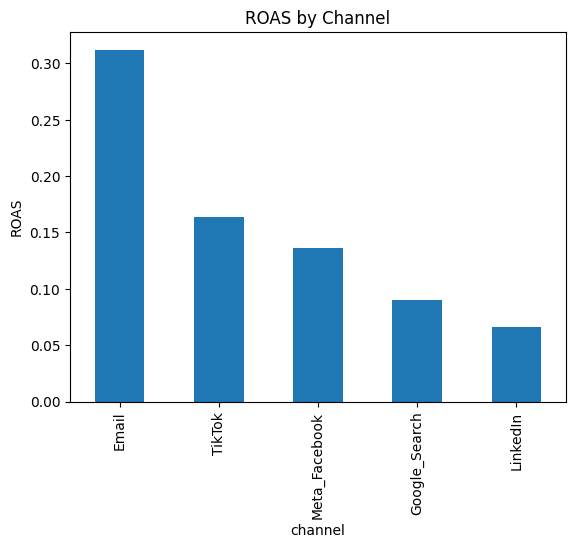

In [108]:
import numpy as np

plot_data = (
    roas_df["roas"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)

plot_data.plot(kind="bar")

plt.title("ROAS by Channel")
plt.ylabel("ROAS")
plt.show()

In [109]:
campaign_revenue = (
    crm_df
    .groupby(
        "last_touch_campaign"
    )
    ["revenue_usd"]
    .sum()
    .sort_values(
        ascending=False
    )
)

campaign_revenue.head(10)

last_touch_campaign
FB_Awareness          17140.34
GSearch_Generic       14732.03
TikTok_Promo          14633.88
GSearch_Brand         14321.60
FB_Lookalike          13815.57
GSearch_Competitor    12988.80
Organic_SEO            8958.13
FB_Retargeting         8655.36
LinkedIn_B2B           8569.79
TikTok_Video1          8347.51
Name: revenue_usd, dtype: float64

In [110]:
attribution_summary = pd.DataFrame({
    "Channel":
        roas_df.index,
    "Spend":
        roas_df["spend"],
    "Revenue":
        roas_df["revenue"],
    "ROAS":
        roas_df["roas"]
})

attribution_summary

,Channel,Spend,Revenue,ROAS
channel,,,,
Email,Email,45909.35,14329.86,0.312134
Google_Search,Google_Search,483302.68,43583.44,0.090178
LinkedIn,LinkedIn,252163.24,16716.83,0.066294
Meta_Facebook,Meta_Facebook,304221.15,41564.63,0.136626
Organic,Organic,0.00,16696.59,NaN
TikTok,TikTok,150570.08,24587.92,0.163299


## Key Findings

- Email campaigns achieved the highest paid ROAS.
- Organic traffic generated revenue without advertising spend.
- Google Search had the highest spend but comparatively lower ROAS.

## Channel Performance Analysis

### Best Performing Channel

Email marketing achieved the highest paid Return on Ad Spend (ROAS), indicating efficient campaign performance and strong revenue generation relative to advertising costs.

### Lowest Performing Channel

LinkedIn generated the lowest ROAS among the paid channels, suggesting opportunities to optimize campaign targeting, audience selection, or advertising strategy.

### Organic Traffic

Organic traffic generated revenue without direct advertising expenditure, highlighting the importance of search engine optimization (SEO) and organic customer acquisition.

## Recommendations

Based on the analysis, the following recommendations are proposed:

- Increase investment in high-performing marketing channels.
- Review and optimize campaigns with lower ROAS.
- Continue leveraging organic traffic through SEO initiatives.
- Monitor campaign performance regularly using KPI dashboards.
- Perform A/B testing to improve advertisement effectiveness.

## Executive Summary

This project successfully analyzed marketing campaign performance using Python, SQL, and Power BI.

Key outcomes include:

- Cleaned and validated marketing datasets
- Business KPI calculations
- Attribution modeling
- SQL database integration
- Interactive dashboard development

The insights generated can support data-driven marketing decisions and budget optimization.